In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for our visualizations
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
# 1. Load the Pedestrian Data
pedestrians_df = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/data/pedestrians.csv')
segments_df = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/segments.csv')

print(f"Pedestrians Data Shape: {pedestrians_df.shape}")
print(f"Segments Data Shape: {segments_df.shape}")

# 2. Load the Transit Data (just stops and routes for now)
stops_df = pd.read_csv('data/MTS Data/stops.txt')
routes_df = pd.read_csv('data/MTS Data/routes.txt')

print(f"\nMTS Stops Shape: {stops_df.shape}")
print(f"MTS Routes Shape: {routes_df.shape}")

# 3. Take a peek at the first 5 rows of the pedestrian data
display(pedestrians_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'data/cityiq.io-pedestrians-san_diego-1/segments.csv'

In [ ]:
# 1. Load the Pedestrian Data
pedestrians_df = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/data/pedestrians.csv')
# Updated path below to include the /notebooks/ folder!
segments_df = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/notebooks/segments.csv')

print(f"Pedestrians Data Shape: {pedestrians_df.shape}")
print(f"Segments Data Shape: {segments_df.shape}")

# 2. Load the Transit Data (just stops and routes for now)
stops_df = pd.read_csv('data/MTS Data/stops.txt')
routes_df = pd.read_csv('data/MTS Data/routes.txt')

print(f"\nMTS Stops Shape: {stops_df.shape}")
print(f"MTS Routes Shape: {routes_df.shape}")

# 3. Take a peek at the first 5 rows of the pedestrian data
display(pedestrians_df.head())

Pedestrians Data Shape: (31502953, 5)
Segments Data Shape: (11269, 7)

MTS Stops Shape: (4373, 14)
MTS Routes Shape: (105, 11)


,timestamp,locationuid,direction,speed,count
0,2018-11-01 08:00:00,004361eb,165,2.641,1
1,2018-11-01 09:15:00,004361eb,165,2.641,1
2,2018-11-01 11:45:00,004361eb,165,2.641,1
3,2018-11-01 11:45:00,004361eb,345,2.641,1
4,2018-11-01 12:45:00,004361eb,165,2.641,1


In [ ]:
# 1. Check the data types to see if dates/times are currently just strings (objects)
print("--- Pedestrian Data Info ---")
pedestrians_df.info()

print("\n--- Missing Values Check ---")
# 2. Count how many empty cells exist in each column
missing_values = pedestrians_df.isnull().sum()
print(missing_values[missing_values > 0]) # Only show columns that actually have missing data

# 3. Look at the basic statistical spread of our numbers
display(pedestrians_df.describe())

--- Pedestrian Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 31502953 entries, 0 to 31502952
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   timestamp    str    
 1   locationuid  str    
 2   direction    int64  
 3   speed        float64
 4   count        int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 1.2 GB

--- Missing Values Check ---
Series([], dtype: int64)


,direction,speed,count
count,3.150295e+07,3.150295e+07,3.150295e+07
mean,1.834278e+02,2.026961e+00,4.593354e+00
std,1.094149e+02,8.857956e-01,8.388960e+00
min,-1.000000e+00,0.000000e+00,1.000000e+00
25%,9.000000e+01,1.494250e+00,1.000000e+00
50%,1.800000e+02,2.247167e+00,2.000000e+00
75%,2.700000e+02,2.641000e+00,5.000000e+00
max,3.600000e+02,1.492023e+02,1.190000e+03


In [ ]:
# Convert timestamp from string to actual datetime objects
print("Converting timestamps... this may take a minute or two...")
pedestrians_df['timestamp'] = pd.to_datetime(pedestrians_df['timestamp'])

# Extract the hour and day of the week to make plotting easier later
pedestrians_df['hour'] = pedestrians_df['timestamp'].dt.hour
pedestrians_df['day_of_week'] = pedestrians_df['timestamp'].dt.day_name()

print("Timestamps converted successfully!")
display(pedestrians_df[['timestamp', 'hour', 'day_of_week']].head())

Converting timestamps... this may take a minute or two...
Timestamps converted successfully!


,timestamp,hour,day_of_week
0,2018-11-01 08:00:00,8,Thursday
1,2018-11-01 09:15:00,9,Thursday
2,2018-11-01 11:45:00,11,Thursday
3,2018-11-01 11:45:00,11,Thursday
4,2018-11-01 12:45:00,12,Thursday


Calculating hourly averages...


C:\Users\akash\AppData\Local\Temp\ipykernel_22496\2319020367.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_counts, x='hour', y='count', palette='magma')


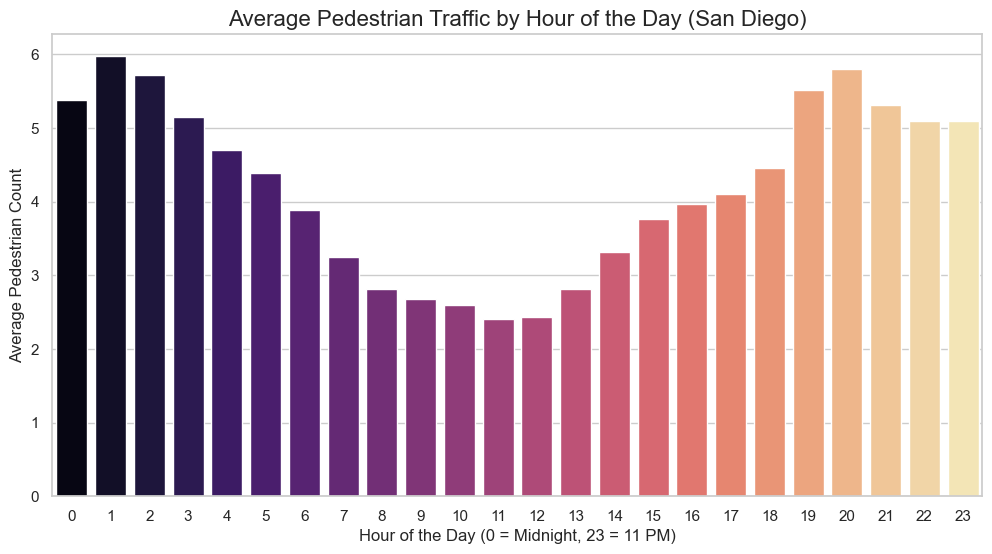

In [ ]:
# 1. Group the data by hour and calculate the average count
print("Calculating hourly averages...")
hourly_counts = pedestrians_df.groupby('hour')['count'].mean().reset_index()

# 2. Set up the figure size
plt.figure(figsize=(12, 6))

# 3. Create a bar plot using Seaborn
sns.barplot(data=hourly_counts, x='hour', y='count', palette='magma')

# 4. Add labels and a title to make it readable
plt.title('Average Pedestrian Traffic by Hour of the Day (San Diego)', fontsize=16)
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)', fontsize=12)
plt.ylabel('Average Pedestrian Count', fontsize=12)

# 5. Display the plot
plt.show()

In [1]:
import geopandas as gpd
import pandas as pd
from shapely import wkt
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMapWithTime

ModuleNotFoundError: No module named 'folium'

In [2]:
%pip install folium

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached charset_normalizer-3.4.7-cp313-cp313-win_amd64.whl.metadata (41 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached charset_normalizer-3.4.7-cp313-cp313-win_amd64.whl (158 kB)
Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl (15 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import geopandas as gpd
import pandas as pd
from shapely import wkt
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMapWithTime

In [5]:
# 1. Load your datasets (Adjust file paths if needed)
peds_df = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/data/pedestrians.csv')
segs_df = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/data/segments.csv')

# 2. Merge the counts with the geographic segments 
# Note: Check your dataframes to ensure 'locationUid' is the correct shared ID column
df_merged = pd.merge(peds_df, segs_df, on='locationUid')

# 3. Extract Latitude and Longitude from the WKT geometry
# We will use the centroid (middle point) of each walkway segment for the heat points
df_merged['geometry'] = df_merged['geometry'].apply(wkt.loads) # Change 'geometry' to your WKT column name if different
gdf = gpd.GeoDataFrame(df_merged, geometry='geometry')

# Extract Lat/Lon
df_merged['lat'] = gdf.geometry.centroid.y
df_merged['lon'] = gdf.geometry.centroid.x

# 4. Ensure your 'hour' column exists (based on your bar chart, you likely have this)
# If not, uncomment and adapt this line:
# df_merged['hour'] = pd.to_datetime(df_merged['time']).dt.hour

KeyError: 'locationUid'

In [6]:
print("Pedestrians columns:", peds_df.columns.tolist())
print("Segments columns:", segs_df.columns.tolist())

Pedestrians columns: ['timestamp', 'locationuid', 'direction', 'speed', 'count']
Segments columns: ['Unnamed: 0', 'roadsegid', 'tod', 'dow', 'speed', 'count', 'geometry']


In [8]:
# 1. Load your datasets
peds_df = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/data/pedestrians.csv')
segs_df = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/data/segments.csv')

# 2. FIX THE DATA TYPES BEFORE MERGING
# Convert both to strings, and remove any accidental '.0' from the float numbers
peds_df['locationuid'] = peds_df['locationuid'].astype(str).str.replace(r'\.0$', '', regex=True)
segs_df['roadsegid'] = segs_df['roadsegid'].astype(str).str.replace(r'\.0$', '', regex=True)

# 3. Merge using the cleaned column names
df_merged = pd.merge(peds_df, segs_df, left_on='locationuid', right_on='roadsegid')

# Rename 'count_x' back to 'count'
df_merged = df_merged.rename(columns={'count_x': 'count'})

# 4. Extract Latitude and Longitude from the WKT geometry
df_merged['geometry'] = df_merged['geometry'].apply(wkt.loads) 
gdf = gpd.GeoDataFrame(df_merged, geometry='geometry')

# Extract Lat/Lon from the centroid
df_merged['lat'] = gdf.geometry.centroid.y
df_merged['lon'] = gdf.geometry.centroid.x

# 5. Create the 'hour' column using your 'timestamp' column
df_merged['hour'] = pd.to_datetime(df_merged['timestamp']).dt.hour

print("Merge successful! You have", len(df_merged), "rows ready to map.")

Merge successful! You have 0 rows ready to map.


In [9]:
# Let's peek at the first 5 IDs from both datasets to see how they differ
print("Pedestrian IDs:")
print(peds_df['locationuid'].head().tolist())

print("\nSegment IDs:")
print(segs_df['roadsegid'].head().tolist())

Pedestrian IDs:
['004361eb', '004361eb', '004361eb', '004361eb', '004361eb']

Segment IDs:
['239', '239', '239', '239', '239']


In [10]:
import os

# List all files in your dataset folder
folder_path = 'data/cityiq.io-pedestrians-san_diego-1/data/'
files = os.listdir(folder_path)
print("Files in my dataset folder:", files)

Files in my dataset folder: ['pedestrians.csv', 'segments.csv']


In [ ]:
import geopandas as gpd
import pandas as pd
from shapely import wkt
import folium
from folium.plugins import HeatMapWithTime

# 1. Load just the segments file (it already has our counts and geometry!)
segs_df = pd.read_csv('data/cityiq.io-pedestrians-san_diego-1/data/segments.csv')

# 2. Extract Latitude and Longitude from the WKT string
segs_df['geometry'] = segs_df['geometry'].apply(wkt.loads) 
gdf = gpd.GeoDataFrame(segs_df, geometry='geometry')

# We'll use the centroid (middle point) of each segment for our heatmap
segs_df['lat'] = gdf.geometry.centroid.y
segs_df['lon'] = gdf.geometry.centroid.x

# 3. Group the data by "Time of Day" (tod) and get the average pedestrian count
grouped = segs_df.groupby(['tod', 'lat', 'lon'])['count'].mean().reset_index()

## Create a manual list in the exact chronological order you want the slider to play
time_periods = ['morning', 'lunch', 'afternoon', 'evening', 'night']

# 4. Format for Folium's HeatMapWithTime
heat_data = []
time_index = []

for time_period in time_periods:
    # Filter for the current time period
    time_data = grouped[grouped['tod'] == time_period]
    
    # Create a list of [lat, lon, weight] 
    locations_with_weight = time_data[['lat', 'lon', 'count']].values.tolist()
    
    heat_data.append(locations_with_weight)
    
    # The label for the slider (e.g., 'morning', 'afternoon')
    time_index.append(f"Time: {time_period}")

# 5. Render the Map!
san_diego_coords = [32.7157, -117.1611]
m = folium.Map(location=san_diego_coords, zoom_start=13, tiles='CartoDB dark_matter')

HeatMapWithTime(
    data=heat_data,
    index=time_index,
    radius=15,          
    auto_play=True,     
    max_opacity=0.8
).add_to(m)

# Save the map to an HTML file instead of displaying it in the notebook
m.save('san_diego_heatmap.html')